In [ ]:
# Google Drive 마운트
from google.colab import drive,files
drive.mount('/content/drive')
uploaded = files.upload()  # requirements.txt 업로드
!pip install -r requirements.txt

Mounted at /content/drive


Saving requirements.txt to requirements.txt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.6 MB/s eta 0:00:00


In [ ]:
import os
import torch
import numpy as np
import rasterio
from torchvision import transforms
from tqdm import tqdm
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import jaccard_score

# --- 데이터가 저장된 기본 경로 설정 ---
base_dir = '/content/drive/MyDrive/53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터'
train_img_dir = os.path.join(base_dir, 'Training/01.원천데이터/TS_SN10')
train_label_dir = os.path.join(base_dir, 'Training/02.라벨링데이터/TL_SN10')
val_img_dir = os.path.join(base_dir, 'Validation/01.원천데이터/VS_SN10')
val_label_dir = os.path.join(base_dir, 'Validation/02.라벨링데이터/VL_SN10')


In [ ]:
# 이미지와 라벨을 불러와 텐서로 변환하고 리스트에 저장하는 함수를 정의합니다.
def preprocess_all_data(img_dir, label_dir, desc):
    data_list = []
    img_files = sorted(os.listdir(img_dir))
    label_files = sorted(os.listdir(label_dir))

    img_names = {os.path.splitext(f)[0] for f in img_files if f.endswith('.tif')}
    label_names = {os.path.splitext(f)[0] for f in label_files if f.endswith('.tif')}
    common_names = sorted(list(img_names.intersection(label_names)))

    print(f"총 {len(common_names)}개의 데이터 쌍을 전처리합니다. 시간이 오래 걸릴 수 있습니다...")

    # tqdm: for 루프의 진행 상황을 progress bar로 보여줍니다. desc는 바의 제목입니다.
    for name in tqdm(common_names, desc=desc):
        img_path = os.path.join(img_dir, name + '.tif')
        label_path = os.path.join(label_dir, name + '.tif')

        try:
            with rasterio.open(img_path) as src:
                image_array = src.read()
            with rasterio.open(label_path) as src:
                label_array = src.read(1)

            image_tensor = torch.from_numpy(image_array).float() / 65535.0

            label_array = (label_array == 10).astype(np.int64)
            label_tensor = torch.from_numpy(label_array).long()

            data_list.append({
                'image': image_tensor,
                'label': label_tensor
            })
        except Exception as e:
            print(f"Warning: 파일 {name} 처리 중 오류 발생 - {e}. 이 파일을 건너뜁니다.")
            continue

    return data_list

# 전처리 결과 캐시 경로 (한 번 전처리하면 재실행 시 건너뜀)
TRAIN_CACHE_PATH = os.path.join(base_dir, 'train_preprocessed.pt')
VAL_CACHE_PATH = os.path.join(base_dir, 'val_preprocessed.pt')

if os.path.exists(TRAIN_CACHE_PATH) and os.path.exists(VAL_CACHE_PATH):
    print("전처리 캐시가 이미 존재합니다. 전처리를 건너뛰고 캐시를 사용합니다.")
    train_data_preprocessed = torch.load(TRAIN_CACHE_PATH, map_location='cpu')
    val_data_preprocessed = torch.load(VAL_CACHE_PATH, map_location='cpu')
else:
    train_data_preprocessed = preprocess_all_data(train_img_dir, train_label_dir, desc='Processing Training Data')
    val_data_preprocessed = preprocess_all_data(val_img_dir, val_label_dir, desc='Processing Validation Data')

    torch.save(train_data_preprocessed, TRAIN_CACHE_PATH)
    torch.save(val_data_preprocessed, VAL_CACHE_PATH)

print("\n데이터 전처리 준비 완료!")
print(f"최종 훈련 데이터 개수: {len(train_data_preprocessed)}개")
print(f"최종 검증 데이터 개수: {len(val_data_preprocessed)}개")

총 8000개의 데이터 쌍을 전처리합니다. 시간이 오래 걸릴 수 있습니다...


Processing Training Data:   0%|          | 0/8000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
Processing Training Data: 100%|██████████| 8000/8000 [4:03:06<00:00,  1.82s/it]


총 1000개의 데이터 쌍을 전처리합니다. 시간이 오래 걸릴 수 있습니다...


Processing Validation Data: 100%|██████████| 1000/1000 [02:12<00:00,  7.52it/s]



데이터 전처리 및 저장 완료!
최종 저장된 훈련 데이터 개수: 8000개
최종 저장된 검증 데이터 개수: 1000개


In [ ]:
import torch
import numpy as np
import random
import os
from torch.utils.data import Dataset, DataLoader

# 데이터 증강을 위한 Albumentations 라이브러리 import
import albumentations as A
from albumentations.pytorch import ToTensorV2

# -------------------------------------------------------------
# 1. 재현성(항상 같은 결과가 나오도록)을 위해 랜덤 시드를 고정하는 함수
# -------------------------------------------------------------
def set_seed(seed):
    """재현성을 위해 각종 시드를 고정하는 함수"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if use multi-GPU
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -------------------------------------------------------------
# 2. 성능 향상을 위한 데이터셋 클래스
# -------------------------------------------------------------
class PreprocessedDataset(Dataset):
  # 데이터셋이 처음 생성될 때 실행되는 초기화 함수
    def __init__(self, data_file, augment=False):
        self.data = torch.load(data_file, map_location='cpu')
        self.augment = augment
        if self.augment:
            self.transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),
                A.CoarseDropout(max_holes=8, max_height=32, max_width=32, min_holes=1, fill_value=0, p=0.5),
                A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.5),
                A.GridDistortion(p=0.5),
                A.OpticalDistortion(distort_limit=0.5, shift_limit=0.5, p=0.5),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image_tensor = item['image']
        image_numpy = (image_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        label_tensor = item['label']
        label_numpy = label_tensor.numpy()
        transformed = self.transform(image=image_numpy, mask=label_numpy)
        image = transformed['image'].float() / 255.0
        label = transformed['mask'].long()
        return image, label

# -------------------------------------------------------------
# 3. 데이터로더 설정
# -------------------------------------------------------------
SEED = 42
set_seed(SEED)

train_dataset = PreprocessedDataset(
    data_file=os.path.join(base_dir, 'train_preprocessed.pt'),
    augment=True
)
val_dataset = PreprocessedDataset(
    data_file=os.path.join(base_dir, 'val_preprocessed.pt'),
    augment=False
)

# 한 번의 스텝(step)에서 모델이 학습할 데이터의 개수를 32로 설정합니다.
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("✅ 데이터셋 및 데이터로더 설정 완료 (Augmentation Further Enhanced)!")

/tmp/ipython-input-4182498725.py:38: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, min_holes=1, fill_value=0, p=0.5),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-4182498725.py:41: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.5, shift_limit=0.5, p=0.5),


✅ 데이터셋 및 데이터로더 설정 완료 (Augmentation Further Enhanced)!


In [ ]:
import segmentation_models_pytorch as smp
import torch.nn as nn

# -------------------------------------------------------------
# 1. 모델 아키텍처 정의
# -------------------------------------------------------------

# 인코더 이름을 변수로 저장
ENCODER_NAME = "resnet34"

# U-Net 아키텍처에 사전 학습된 ResNet34를 인코더로 사용
model = smp.Unet(
    encoder_name=ENCODER_NAME,        # 변수를 사용하여 인코더 지정
    encoder_weights="imagenet",     # ImageNet 가중치를 불러와 사용
    in_channels=4,                  # 입력 채널
    classes=2,                      # 출력 클래스
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# print 구문에서 model.encoder.name 대신 변수 사용
print(f"✅ Segmentation Models Pytorch (Unet with {ENCODER_NAME}) 모델 설정 완료!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

✅ Segmentation Models Pytorch (Unet with resnet34) 모델 설정 완료!


Epoch 1/80 (Validation): 100%|██████████| 32/32 [00:25<00:00,  1.27it/s]


Epoch [1/80], Loss: 0.7132, Validation mIoU: 0.8188, LR: 0.000100, Time: 101.55s
🎉 Best mIoU updated to 0.8188 at Epoch 1. Model saved!


Epoch 2/80 (Validation): 100%|██████████| 32/32 [00:25<00:00,  1.28it/s]


Epoch [2/80], Loss: 0.5733, Validation mIoU: 0.8301, LR: 0.000100, Time: 98.75s
🎉 Best mIoU updated to 0.8301 at Epoch 2. Model saved!


Epoch 3/80 (Validation): 100%|██████████| 32/32 [00:24<00:00,  1.29it/s]


...

Epoch [78/80], Loss: 0.3951, Validation mIoU: 0.9212, LR: 0.000001, Time: 98.64s
🎉 Best mIoU updated to 0.9212 at Epoch 78. Model saved!


Epoch 79/80 (Validation): 100%|██████████| 32/32 [00:24<00:00,  1.29it/s]


Epoch [79/80], Loss: 0.3999, Validation mIoU: 0.9213, LR: 0.000001, Time: 98.87s
🎉 Best mIoU updated to 0.9213 at Epoch 79. Model saved!


Epoch 80/80 (Validation): 100%|██████████| 32/32 [00:24<00:00,  1.29it/s]


Epoch [80/80], Loss: 0.3930, Validation mIoU: 0.9211, LR: 0.000001, Time: 98.41s

🚀 학습 완료! 최종 Best mIoU: 0.9213 (Epoch 79)


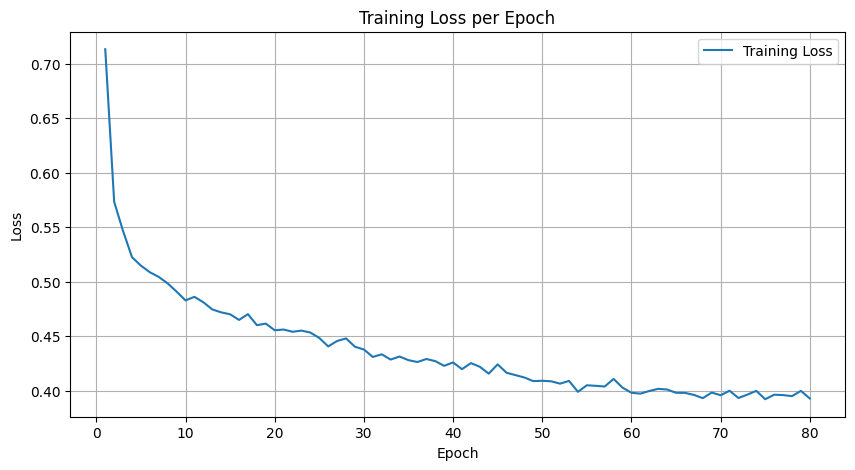

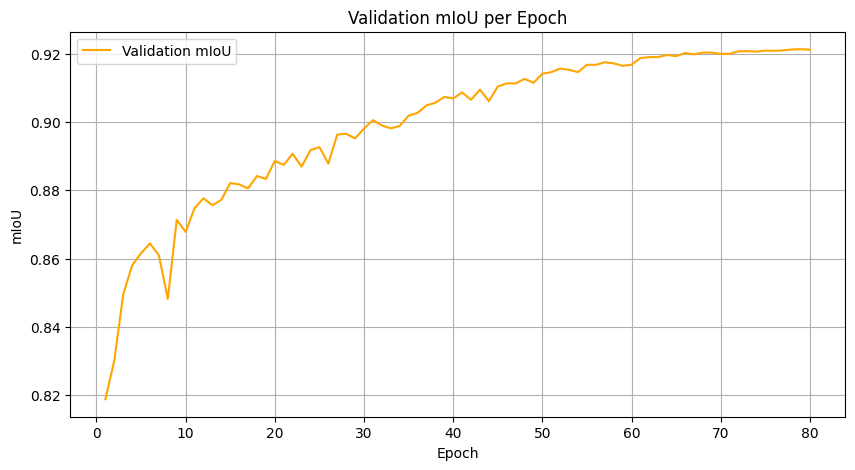

In [ ]:
import time
import matplotlib.pyplot as plt
import os
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import jaccard_score
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

# -------------------------------------------------------------
# 1. DiceLoss 클래스 및 mIoU 함수 정의
# -------------------------------------------------------------
# nn.Module을 상속받아 이미지 분할에 특화된 Dice Loss를 직접 정의합니다.
class DiceLoss(torch.nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceLoss, self).__init__()
    # 모델의 출력(inputs)과 정답(targets)을 받아 손실 값을 계산하는 부분
    def forward(self, inputs, targets, smooth=1):
        inputs = F.softmax(inputs, dim=1)[:, 1] # 클래스 1에 대한 확률만 사용
        inputs = inputs.contiguous().view(-1)
        targets = targets.contiguous().view(-1)
        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)
        return 1 - dice
# mIoU 점수를 계산하는 함수
def calculate_miou(preds, labels):
    preds_flat = preds.cpu().numpy().flatten()
    labels_flat = labels.cpu().numpy().flatten()
    return jaccard_score(labels_flat, preds_flat, average='macro', zero_division=1.0)

# 검증 루프 공통 함수: 학습 중 검증, 베스트 모델 재검증, 최종 시각화에서 모두 재사용
def evaluate_model(model, loader, device, desc='Evaluating', collect_predictions=False):
    """주어진 모델/데이터로더에 대해 평균 mIoU를 계산.
    collect_predictions=True면 시각화를 위한 (images, labels, preds) 텐서도 함께 반환."""
    model.eval()
    ious = []
    images_list, labels_list, preds_list = [], [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, total=len(loader), desc=desc):
            images_device, labels_device = images.to(device), labels.to(device)
            outputs = model(images_device)
            preds_prob = torch.softmax(outputs, dim=1)[:, 1, :, :]
            preds = (preds_prob > 0.5).long()
            ious.append(calculate_miou(preds, labels_device))
            if collect_predictions:
                images_list.append(images.cpu())
                labels_list.append(labels.cpu())
                preds_list.append(preds.cpu())

    avg_miou = float(np.mean(ious))
    if collect_predictions:
        return avg_miou, torch.cat(images_list), torch.cat(labels_list), torch.cat(preds_list)
    return avg_miou

# -------------------------------------------------------------
# 2. 하이퍼파라미터 및 학습 설정
# -------------------------------------------------------------
LEARNING_RATE = 1e-4
NUM_EPOCHS = 80

# 손실 함수 (Loss Function) 인스턴스 생성
criterion = nn.CrossEntropyLoss()
dice_loss = DiceLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)

# 학습률 스케줄러 (Learning Rate Scheduler) 설정: CosineAnnealingLR은 학습률을 점차적으로 부드럽게 감소시켜
# 학습 후반부에 안정적인 최적점을 찾는 데 도움을 줍니다.
# T_max: 학습률이 최대치에서 최소치까지 감소하는 주기(에폭 수)
# eta_min: 학습률이 도달할 수 있는 최솟값
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# 결과 기록용 리스트 초기화
train_losses, val_mious = [], []
best_miou = 0.0
best_epoch = -1
results_dir = os.path.join(base_dir, 'validation_results_v2')
os.makedirs(results_dir, exist_ok=True)

# -------------------------------------------------------------
# 3. 학습 및 검증 루프
# -------------------------------------------------------------
for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # --- 모델 학습 ---
    model.train()
    running_loss = 0.0
    train_loop = tqdm(train_loader, total=len(train_loader), desc=f'Epoch {epoch+1}/{NUM_EPOCHS} (Train)')
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)

        # 손실 함수 조합 (CE + Dice)
        ce_loss = criterion(outputs, labels)
        d_loss = dice_loss(outputs, labels)
        loss = ce_loss + d_loss

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        train_loop.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # --- 모델 검증 ---
    avg_miou = evaluate_model(model, val_loader, device, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} (Validation)')
    val_mious.append(avg_miou)
    end_time = time.time()

    # 스케줄러 업데이트
    scheduler.step()

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {epoch_loss:.4f}, Validation mIoU: {avg_miou:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}, Time: {end_time - start_time:.2f}s")

    # Best mIoU 갱신 및 모델 저장
    if avg_miou > best_miou:
        best_miou = avg_miou
        best_epoch = epoch+1
        torch.save(model.state_dict(), os.path.join(results_dir, 'best_model_v2.pth'))
        print(f"🎉 Best mIoU updated to {best_miou:.4f} at Epoch {best_epoch}. Model saved!")


print(f"\n🚀 학습 완료! 최종 Best mIoU: {best_miou:.4f} (Epoch {best_epoch})")

# 그래프 그리는 부분
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Loss per Epoch')
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), val_mious, label='Validation mIoU', color='orange')
plt.xlabel('Epoch'); plt.ylabel('mIoU'); plt.title('Validation mIoU per Epoch')
plt.legend(); plt.grid(True); plt.show()

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import segmentation_models_pytorch as smp # smp 라이브러리 import

# --- 1. 최고 성능 모델 로드 ---
print("최고 성능으로 저장된 모델(best_model_v2.pth)을 불러옵니다...")

# 모델 정의를 학습 때와 동일한 smp.Unet으로 수정
ENCODER_NAME = "resnet34"
evaluation_model = smp.Unet(
    encoder_name=ENCODER_NAME,
    encoder_weights=None, # 가중치를 불러올 것이므로 None으로 설정
    in_channels=4,
    classes=2,
)

# 파일 경로 지정
results_dir = os.path.join(base_dir, 'validation_results_v2')
model_path = os.path.join(results_dir, 'best_model_v2.pth')

# 가중치 불러오기
evaluation_model.load_state_dict(torch.load(model_path, map_location=device))
evaluation_model.to(device)
print("모델 로드 완료!")


# --- 2. Mission 3 평가 조건으로 검증 수행 (cell-5의 evaluate_model 재사용) ---
avg_eval_miou = evaluate_model(evaluation_model, val_loader, device, desc='Best Model Evaluation')

# --- 3. 최종 결과 출력 ---
print("\n" + "="*50)
print("✅ 최고 성능 모델 (best_model_v2.pth) 최종 검증 결과")
print(f"   - 평가 기준: Sigmoid(Softmax) + Threshold 0.5")
print(f"   - 검증 데이터셋 mIoU: {avg_eval_miou:.4f}")
print("="*50)

if 'best_miou' in locals() or 'best_miou' in globals():
    print(f"\n(참고) 학습 시 기록된 Best mIoU: {best_miou:.4f}")

최고 성능으로 저장된 모델(best_model_v2.pth)을 불러옵니다...
모델 로드 완료!


Best Model Evaluation: 100%|██████████| 32/32 [00:20<00:00,  1.55it/s]


✅ 최고 성능 모델 (best_model_v2.pth) 최종 검증 결과
   - 평가 기준: Sigmoid(Softmax) + Threshold 0.5
   - 검증 데이터셋 mIoU: 0.9213

(참고) 학습 시 기록된 Best mIoU: 0.9213


학습이 완료된 최종 모델을 사용하여 평가 및 시각화를 시작합니다...


Final Model Evaluation: 100%|██████████| 32/32 [00:40<00:00,  1.27s/it]



✅ 최종 모델(50 에폭 시점) 검증 결과
   - 평가 기준: Sigmoid(Softmax) + Threshold 0.5
   - 검증 데이터셋 mIoU: 0.9211

결과 시각화를 위해 랜덤 샘플 5개를 출력합니다...


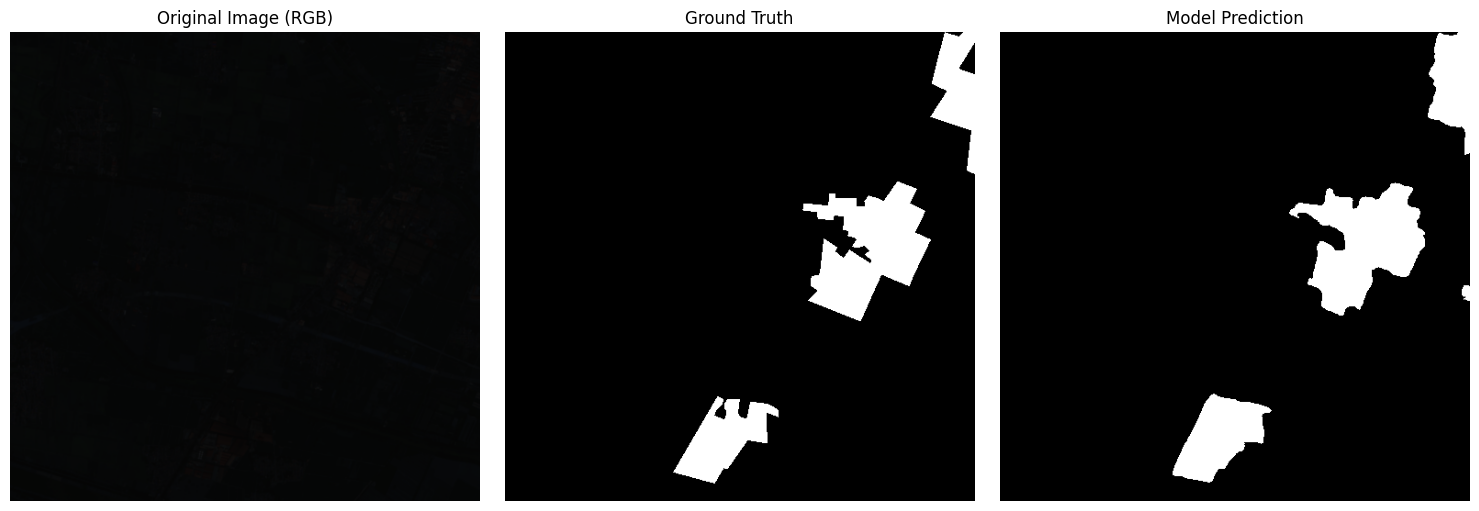

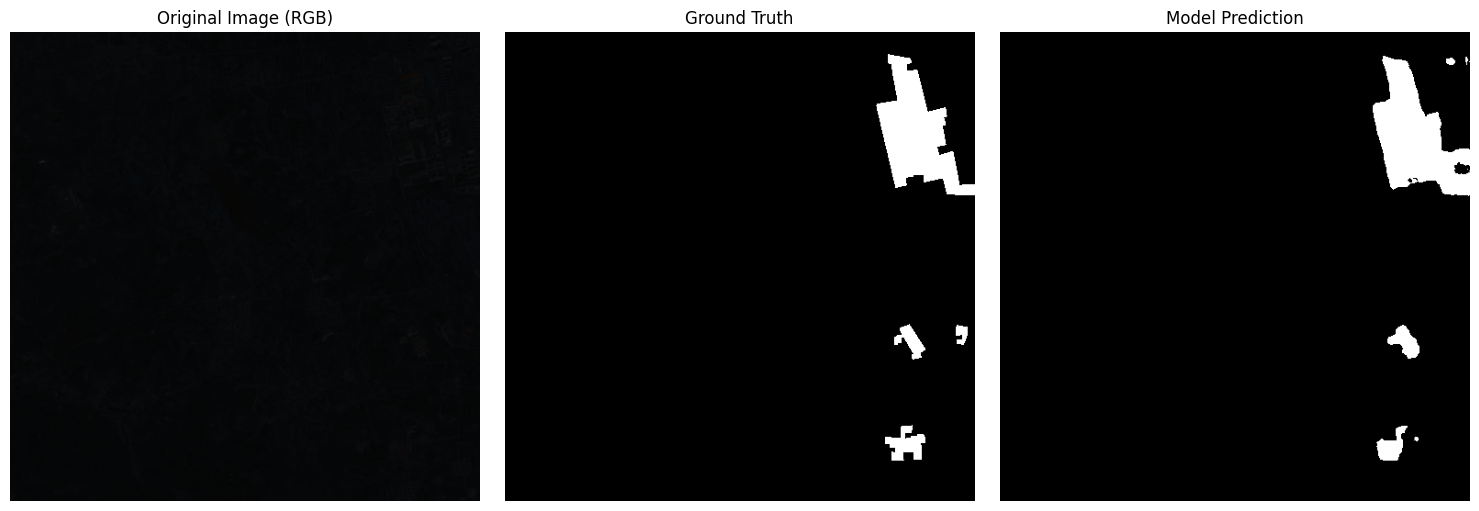

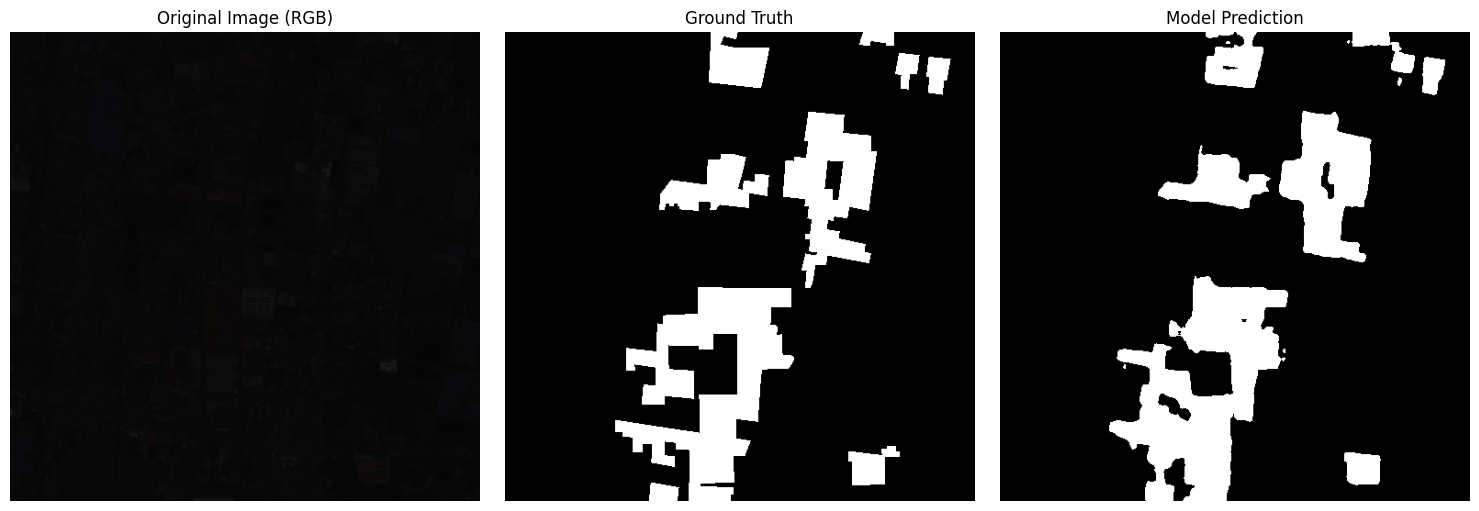

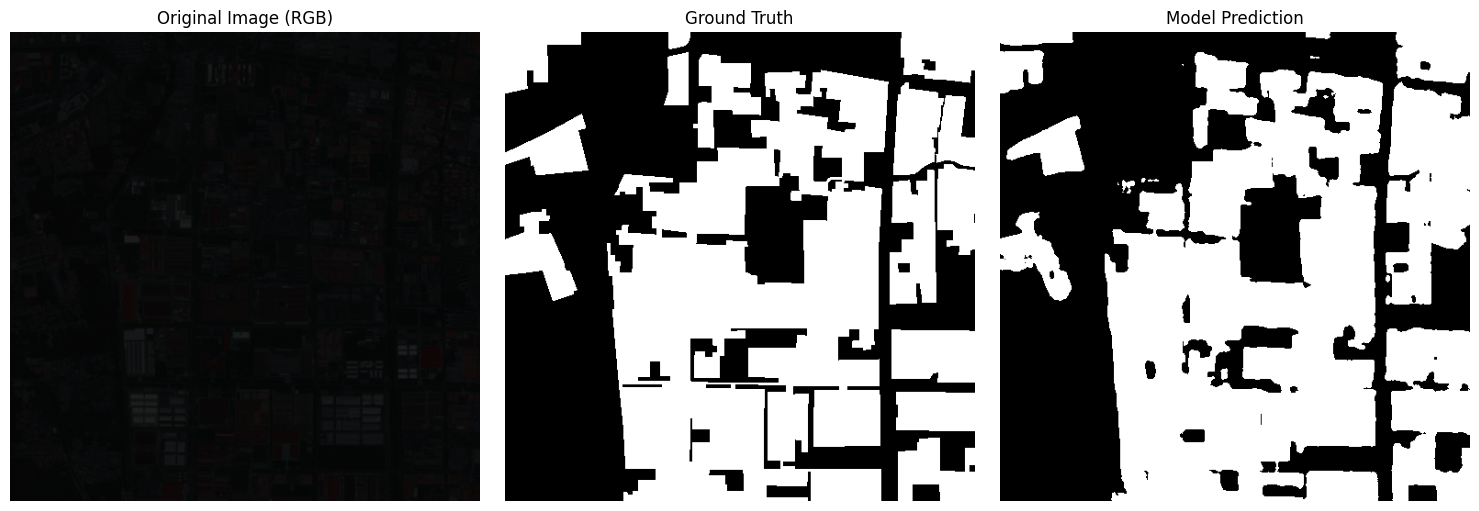

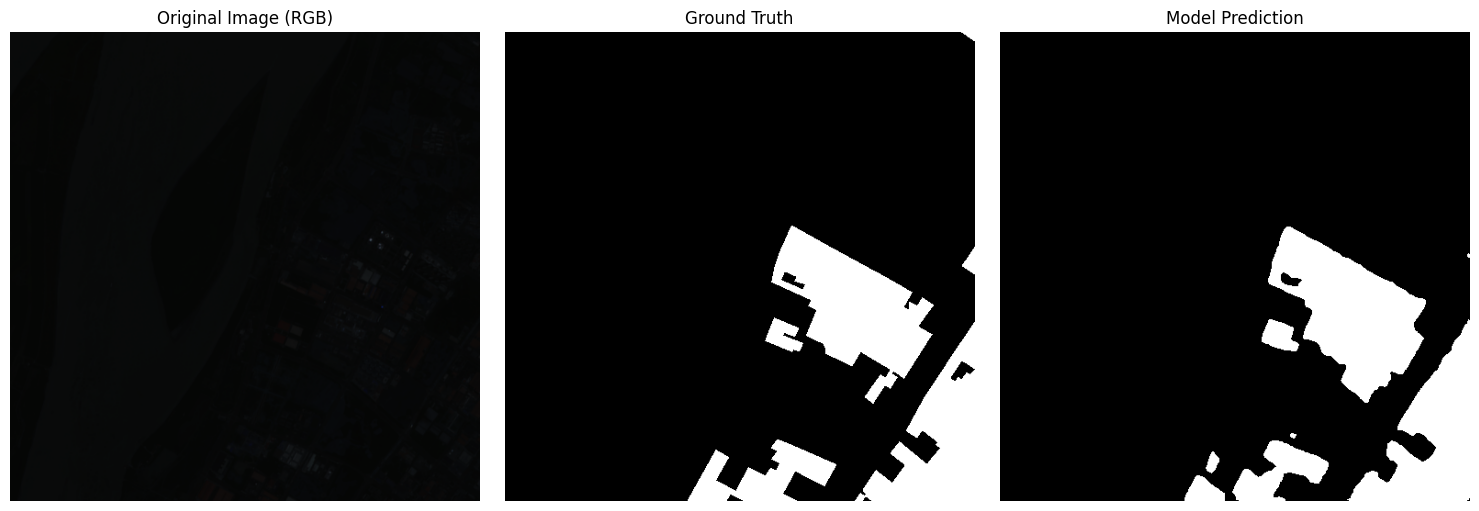

In [ ]:
import random

# --- 1. 현재 학습이 완료된 모델(마지막 에폭 시점)을 평가 모드로 설정 ---
print("학습이 완료된 최종 모델을 사용하여 평가 및 시각화를 시작합니다...")

# --- 2. Mission 3 평가 조건으로 검증 수행 (cell-5의 evaluate_model 재사용) ---
avg_eval_miou, all_images, all_labels, all_preds = evaluate_model(
    model, val_loader, device, desc='Final Model Evaluation', collect_predictions=True
)

# --- 3. 최종 mIoU 결과 출력 ---
print("\n" + "="*50)
print(f"✅ 최종 모델({NUM_EPOCHS} 에폭 시점) 검증 결과")
print(f"   - 평가 기준: Sigmoid(Softmax) + Threshold 0.5")
print(f"   - 검증 데이터셋 mIoU: {avg_eval_miou:.4f}")
print("="*50)

# --- 랜덤 샘플 결과 시각화 ---
print("\n결과 시각화를 위해 랜덤 샘플 5개를 출력합니다...")

# 랜덤하게 5개의 인덱스를 선택합니다.
num_samples_to_show = 5
random_indices = random.sample(range(len(all_images)), k=num_samples_to_show)

for index in random_indices:
    # 시각화할 데이터 선택
    image = all_images[index]
    label = all_labels[index]
    pred = all_preds[index]

    # 위성 이미지를 RGB로 시각화하기 위한 처리 (B, G, R, NIR -> R, G, B)
    # 텐서 형태 (C, H, W) -> 넘파이 (H, W, C)로 변환
    rgb_image = image[[2, 1, 0], :, :].numpy().transpose(1, 2, 0)
    # 픽셀값이 0~1 범위를 벗어날 경우를 대비해 클리핑
    rgb_image = np.clip(rgb_image, 0, 1)

    # 시각화
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(rgb_image)
    axes[0].set_title('Original Image (RGB)')
    axes[0].axis('off')

    axes[1].imshow(label, cmap='gray')
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')

    axes[2].imshow(pred, cmap='gray')
    axes[2].set_title('Model Prediction')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()